In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# טעינת הנתונים - קובץ JSONL
df = pd.read_json('/content/drive/MyDrive/nlp_pro2/data_sets/cleaned/train.full.clean.jsonl', lines=True)


In [7]:
print(df.shape[0])

299728


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. יצירת מפתח משולב לאיזון (הכרחי עבור חלוקה מאוזנת של Genre + Label)
df['stratify_key'] = df['label'].astype(str) + "_" + df['genre'].astype(str)

# 2. ניקוי קבוצות קטנות מדי (פחות מ-3 דגימות) כדי לא לשבור את ה-Split
counts = df['stratify_key'].value_counts()
df = df[~df['stratify_key'].isin(counts[counts < 3].index)]

# 3. חישוב האחוז הנדרש כדי להגיע ל-100,000 ב-Train
# אם היחס הוא 70/15/15, אז ה-Train הוא 70% מהסך הכל.
# סך הכל דגימות שצריך (כדי ש-70% יהיו 100k) הוא: 100,000 / 0.7 = ~142,857
target_total_size = int(100000 / 0.7)
fraction = min(target_total_size / len(df), 1.0)

# 4. דגימה ראשונית של ה-Dataset כולו (כדי להקטין ל-100k ב-Train בסוף)
if fraction < 1.0:
    df_sampled, _ = train_test_split(
        df,
        train_size=target_total_size,
        random_state=42,
        stratify=df['stratify_key']
    )
else:
    df_sampled = df

# 5. חלוקה ל-70% אימון ו-30% היתר (Val+Test)
train_df, temp_df = train_test_split(
    df_sampled,
    test_size=0.30,
    random_state=42,
    stratify=df_sampled['stratify_key']
)

# 6. חלוקת ה-30% הנותרים חצי-חצי (15% ו-15% מהסך הכל)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['stratify_key']
)

# ניקוי עמודת העזר
for d in [train_df, val_df, test_df]:
    d.drop(columns=['stratify_key'], inplace=True)

print(f"Final Counts:")
print(f"Train: {len(train_df)} (Limit was 100,000)")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

Final Counts:
Train: 99999 (Limit was 100,000)
Val:   21429
Test:  21429


In [9]:
import os
# 6. שמירה ל-Google Drive בפורמט JSONL
project_path = '/content/drive/MyDrive/nlp_pro2/data_sets/use_part'
if not os.path.exists(project_path):
    os.makedirs(project_path)

train_df.to_json(f'{project_path}/train.jsonl', orient='records', lines=True, force_ascii=False)
val_df.to_json(f'{project_path}/val.jsonl', orient='records', lines=True, force_ascii=False)
test_df.to_json(f'{project_path}/test.jsonl', orient='records', lines=True, force_ascii=False)

print(f"\nהקבצים נשמרו בנתיב: {project_path}")


הקבצים נשמרו בנתיב: /content/drive/MyDrive/nlp_pro2/data_sets/use_part


In [10]:
!pip install pandas python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 11.1 MB/s eta 0:00:00


In [11]:
import pandas as pd
from bidi.algorithm import get_display

# פונקציה לחישוב אחוזים
def get_label_distribution(df, name):
    dist = df['label'].value_counts(normalize=True) * 100
    return dist.rename(name)

# שילוב התוצאות לטבלה אחת
comparison_df = pd.concat([
    get_label_distribution(train_df, 'Train (%)'),
    get_label_distribution(val_df, 'Validation (%)'),
    get_label_distribution(test_df, 'Test (%)')
], axis=1)

print("--- התפלגות Labels בכל קבוצה (באחוזים) ---")
print(comparison_df.round(2))

--- התפלגות Labels בכל קבוצה (באחוזים) ---
               Train (%)  Validation (%)  Test (%)
label                                             
entailment         33.65           33.65     33.65
contradiction      33.20           33.20     33.20
neutral            33.15           33.15     33.15


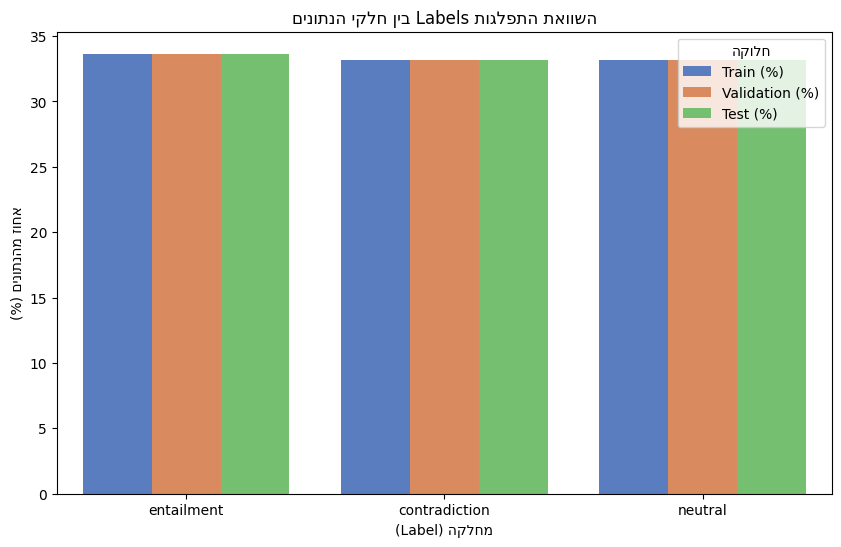

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# הכנת הנתונים לגרף
plot_data = comparison_df.reset_index().melt(id_vars='label', var_name='Split', value_name='Percentage')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='label', y='Percentage', hue='Split', palette='muted')

plt.title(get_display("השוואת התפלגות Labels בין חלקי הנתונים"))
plt.xlabel(get_display("מחלקה (Label)"))
plt.ylabel(get_display("אחוז מהנתונים (%)"))
plt.legend(title=get_display("חלוקה"))
plt.show()

We see the train val and test have the same % of each lebel

In [13]:
import pandas as pd
from bidi.algorithm import get_display

# פונקציה לחישוב אחוזים עבור ז'אנר
def get_genre_distribution(df, name):
    # חישוב אחוזים לכל ז'אנר בשבר עשרוני והכפלה ב-100
    dist = df['genre'].value_counts(normalize=True) * 100
    return dist.rename(name)

# איחוד הנתונים לטבלה אחת להשוואה
genre_comparison_df = pd.concat([
    get_genre_distribution(train_df, 'Train (%)'),
    get_genre_distribution(val_df, 'Validation (%)'),
    get_genre_distribution(test_df, 'Test (%)')
], axis=1).fillna(0) # מילוי ב-0 אם ז'אנר חסר באחת הקבוצות

print("--- התפלגות ז'אנרים בכל קבוצה (באחוזים) ---")
print(genre_comparison_df.round(2))

--- התפלגות ז'אנרים בכל קבוצה (באחוזים) ---
            Train (%)  Validation (%)  Test (%)
genre                                          
government      25.38           25.39     25.38
travel          25.02           25.02     25.02
fiction         24.27           24.28     24.28
slate           23.42           23.43     23.42
letters          0.65            0.64      0.65
oup              0.64            0.64      0.64
nineeleven       0.61            0.61      0.61


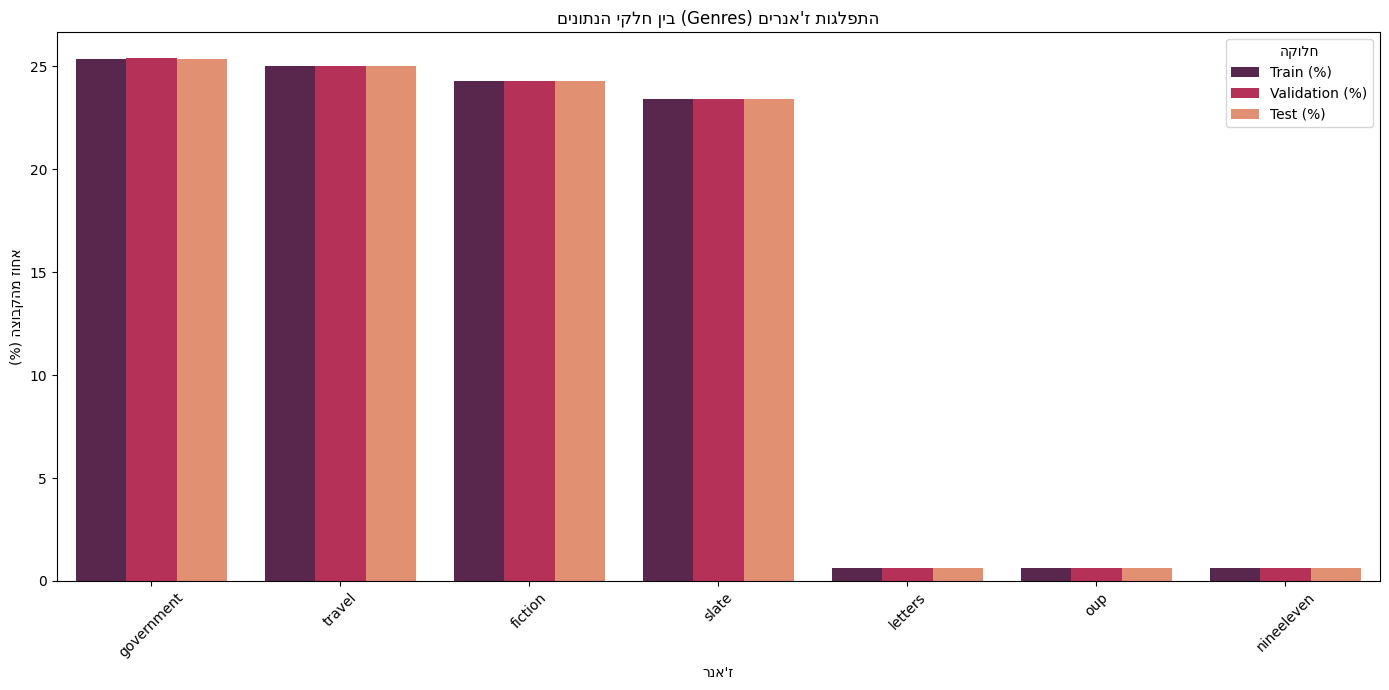

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# הכנת הנתונים למבנה מתאים לגרף
genre_plot_data = genre_comparison_df.reset_index().melt(id_vars='genre', var_name='Split', value_name='Percentage')

plt.figure(figsize=(14, 7))
sns.barplot(data=genre_plot_data, x='genre', y='Percentage', hue='Split', palette='rocket')

plt.title(get_display("התפלגות ז'אנרים (Genres) בין חלקי הנתונים"))
plt.xlabel(get_display("ז'אנר"))
plt.ylabel(get_display("אחוז מהקבוצה (%)"))
plt.xticks(rotation=45)
plt.legend(title=get_display("חלוקה"))
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

def show_detailed_counts(df, name):
    print(f"\n--- כמויות מפורטות עבור: {name} ---")
    # יצירת טבלת הצלבה בין Genre ל-Label
    counts_table = pd.crosstab(df['genre'], df['label'], margins=True, margins_name="סך הכל")
    display(counts_table)

# הרצה על שלושת החלקים
show_detailed_counts(train_df, "Train (אימון)")
show_detailed_counts(val_df, "Validation (ולדיציה)")
show_detailed_counts(test_df, "Test (בחינה)")


--- כמויות מפורטות עבור: Train (אימון) ---


label,contradiction,entailment,neutral,סך הכל
genre,,,,
fiction,8088,8147,8038,24273
government,8444,8486,8453,25383
letters,207,245,193,645
nineeleven,206,216,188,610
oup,207,225,211,643
slate,7769,7917,7737,23423
travel,8280,8409,8333,25022
סך הכל,33201,33645,33153,99999



--- כמויות מפורטות עבור: Validation (ולדיציה) ---


label,contradiction,entailment,neutral,סך הכל
genre,,,,
fiction,1734,1746,1722,5202
government,1810,1818,1812,5440
letters,44,52,41,137
nineeleven,44,46,40,130
oup,44,49,45,138
slate,1665,1697,1658,5020
travel,1774,1802,1786,5362
סך הכל,7115,7210,7104,21429



--- כמויות מפורטות עבור: Test (בחינה) ---


label,contradiction,entailment,neutral,סך הכל
genre,,,,
fiction,1733,1746,1723,5202
government,1809,1819,1811,5439
letters,45,53,41,139
nineeleven,44,47,40,131
oup,45,48,45,138
slate,1664,1696,1658,5018
travel,1774,1802,1786,5362
סך הכל,7114,7211,7104,21429


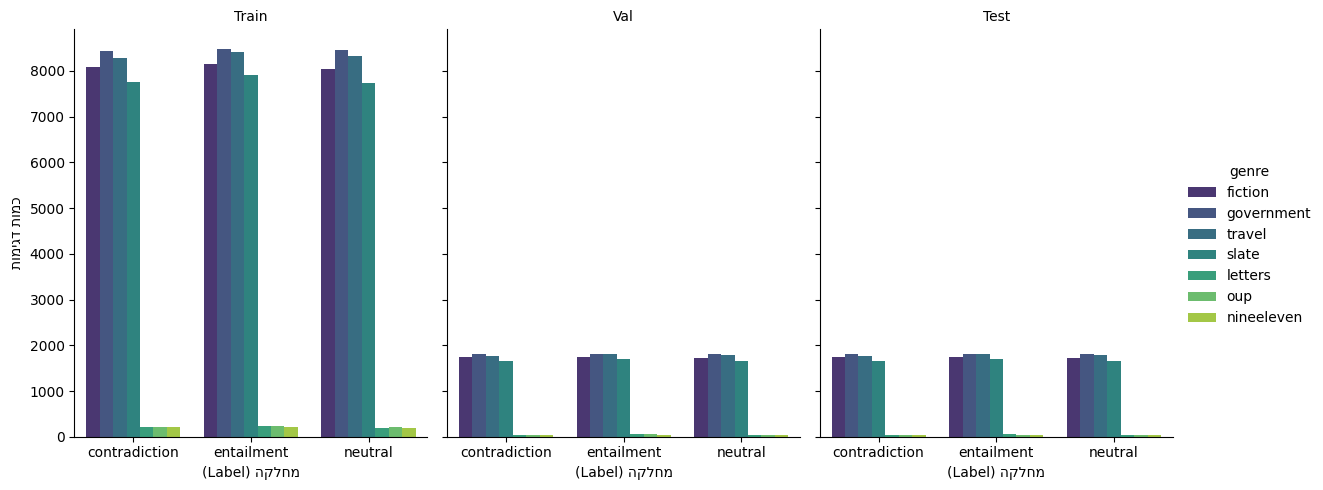

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from bidi.algorithm import get_display

# הכנת דאטה מאוחד לצורך הגרף
train_df['split'] = 'Train'
val_df['split'] = 'Val'
test_df['split'] = 'Test'
combined_df = pd.concat([train_df, val_df, test_df])

# יצירת גרף השוואתי
g = sns.catplot(
    data=combined_df,
    x='label',
    hue='genre',
    col='split',
    kind='count',
    palette='viridis',
    height=5,
    aspect=0.8
)

# התאמת כותרות לעברית
g.set_axis_labels(get_display("מחלקה (Label)"), get_display("כמות דגימות"))
g.set_titles("{col_name}")
plt.show()